In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

Matplotlib is building the font cache; this may take a moment.


In [2]:
#load Dataset
import pandas as pd

df = pd.read_csv("../data/netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
#Data Understanding
df.shape


(8807, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [6]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
#Data Cleaning
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Unknown")

In [9]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64

In [16]:
df["date_added"] = df["date_added"].fillna("Unknown")
df["duration"] = df["duration"].fillna("Unknown")

In [17]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

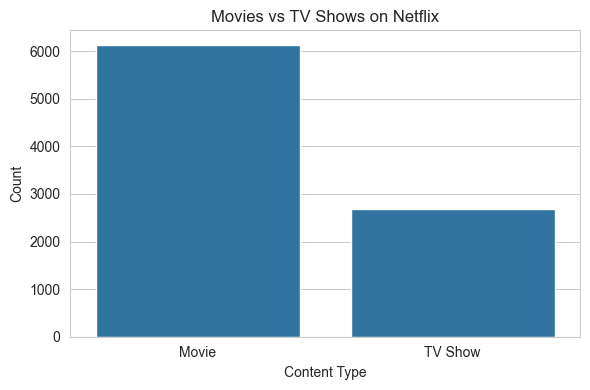

In [52]:
#Movies vs TV Shows Analysis
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="type")

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig("../images/movies_vs_tvshows.png")

plt.show()

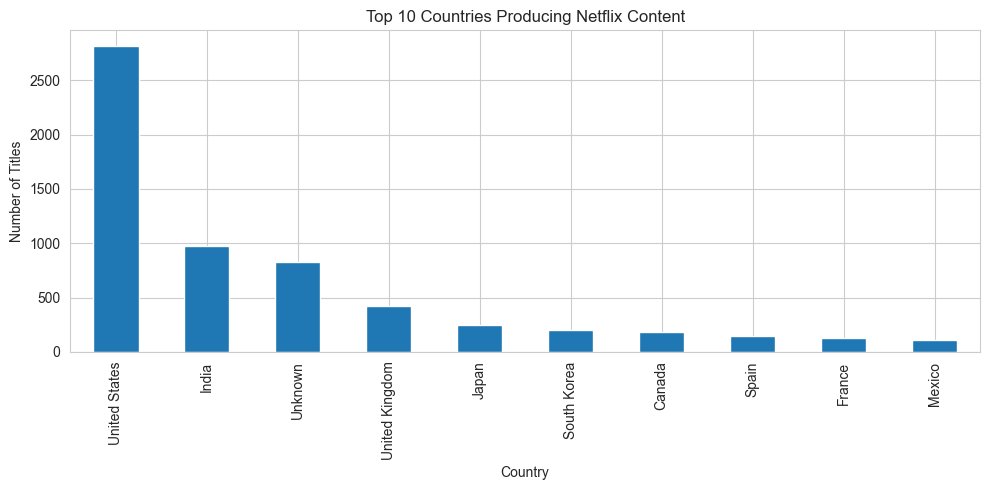

In [53]:
#Top Countries Analysis
top_country = df["country"].value_counts().head(10)
plt.figure(figsize=(10,5))

top_country.plot(kind="bar")

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.tight_layout()

plt.savefig("../images/top_countries.png")

plt.show()


In [27]:
#Content Growth Analysis
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [28]:
df["date_added"].head()

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[us]

In [29]:
df["date_added"].isnull().sum()

np.int64(98)

In [30]:
df["year_added"] = df["date_added"].dt.year

In [31]:
df["year_added"].head()

0    2021.0
1    2021.0
2    2021.0
3    2021.0
4    2021.0
Name: year_added, dtype: float64

In [32]:
year_data = df["year_added"].value_counts().sort_index()

year_data

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

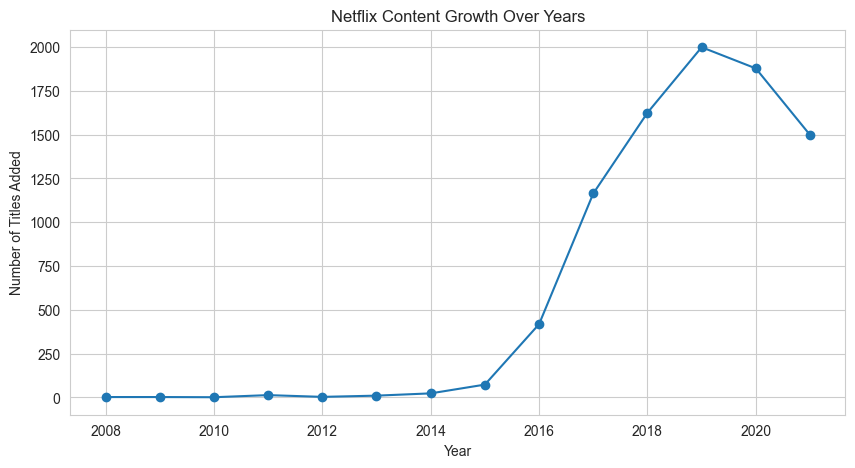

In [34]:
plt.figure(figsize=(10,5))

year_data.plot(marker='o')

plt.title("Netflix Content Growth Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")

plt.savefig("../images/content_growth.png")

plt.show()

In [38]:
df["rating"].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

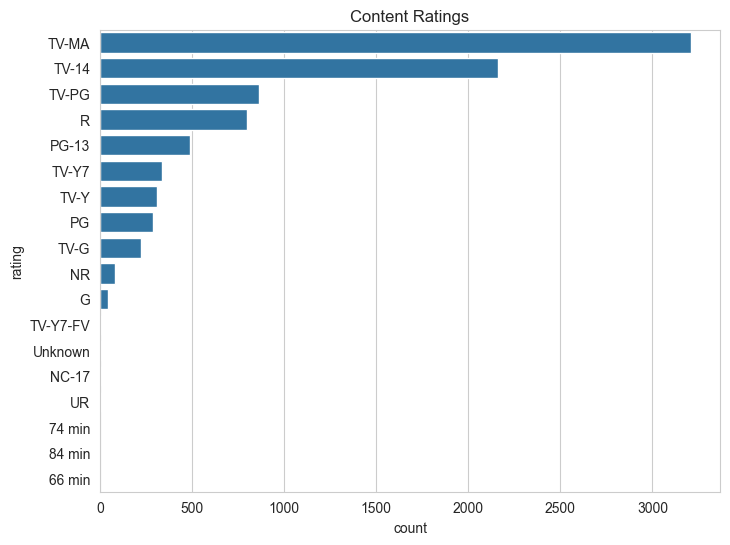

In [39]:
plt.figure(figsize=(8,6))

sns.countplot(
    y=df["rating"],
    order=df["rating"].value_counts().index
)

plt.title("Content Ratings")

plt.show()

In [40]:
df["director"].value_counts().head(10)

director
Unknown                   2634
Rajiv Chilaka               19
Raúl Campos, Jan Suter      18
Suhas Kadav                 16
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Youssef Chahine             12
Martin Scorsese             12
Jay Chapman                 12
Name: count, dtype: int64

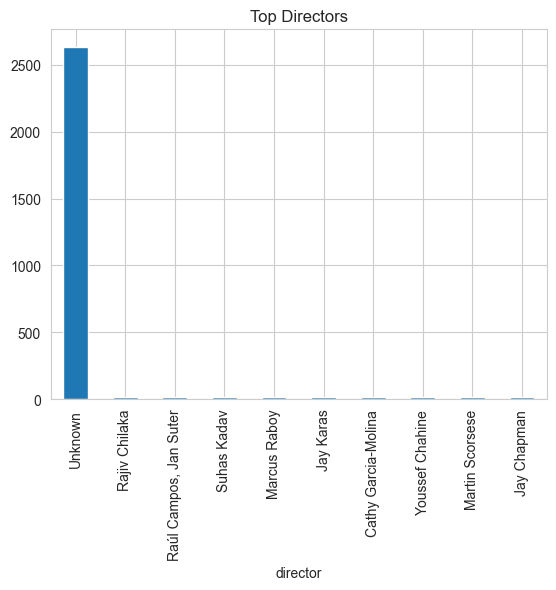

In [41]:
df["director"].value_counts().head(10).plot(kind="bar")

plt.title("Top Directors")

plt.show()

In [42]:
df["month_added"] = df["date_added"].dt.month

In [43]:
month_data = df["month_added"].value_counts().sort_index()

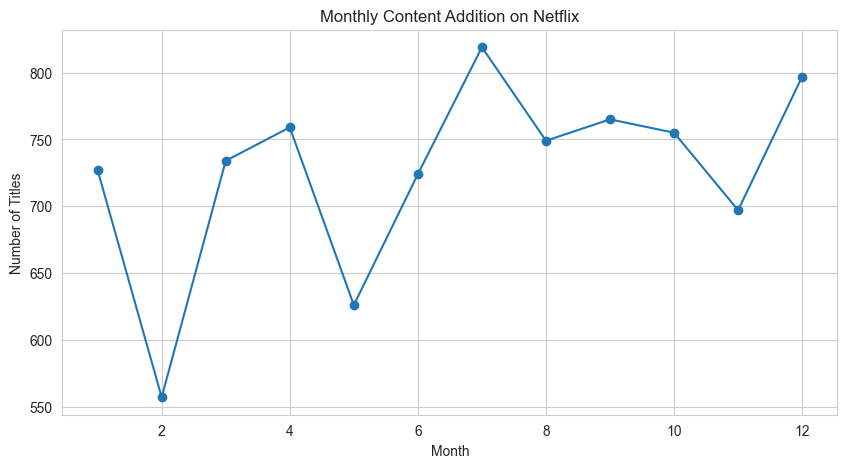

In [46]:
#Monthly Content Addition Analysis
plt.figure(figsize=(10,5))

plt.plot(
    month_data.index,
    month_data.values,
    marker='o'
)

plt.title("Monthly Content Addition on Netflix")
plt.xlabel("Month")
plt.ylabel("Number of Titles")

plt.savefig("../images/monthly_content.png")

plt.show()

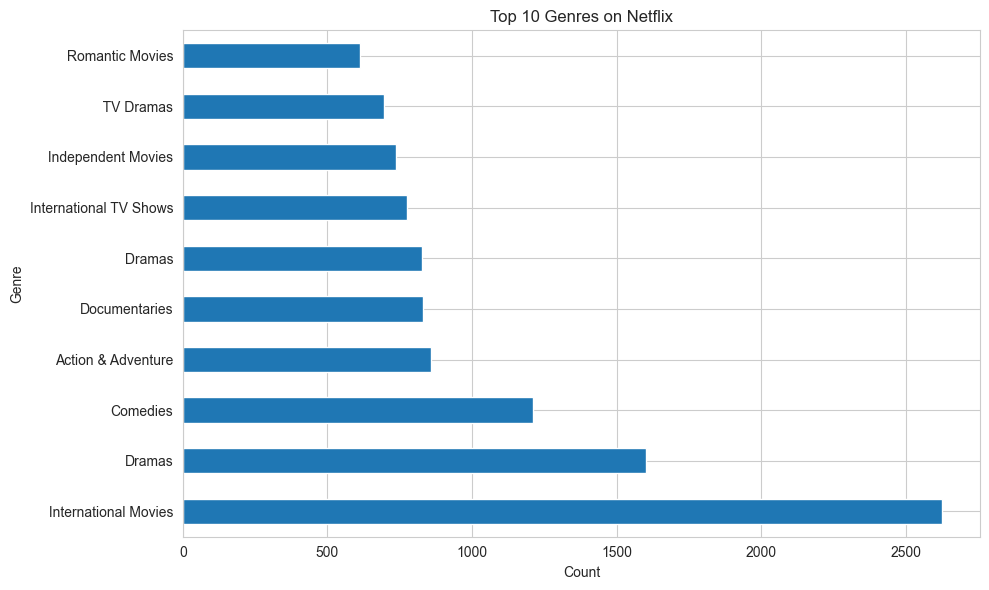

In [54]:
#Top Genres Analysis
genres = df["listed_in"].str.split(",")

genres = genres.explode()

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,6))

top_genres.plot(kind="barh")

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genre")

plt.tight_layout()

plt.savefig("../images/top_genres.png")

plt.show()

# Business Insights

## Insight 1
Movies dominate Netflix's content library.

## Insight 2
The United States contributes the most content.

## Insight 3
Drama and International Movies are among the most popular genres.

## Insight 4
Netflix experienced rapid growth after 2015.

## Insight 5
Content is added throughout the year, showing a continuous content release strategy.

# Recommendations

1. Continue investing in high-performing genres.
2. Increase content production in India and South Korea.
3. Maintain regular content additions.
4. Expand the TV Show catalog.

# Conclusion

This project analyzed Netflix content using Python, Pandas, Matplotlib, and Seaborn. The analysis revealed trends in content type, countries, genres, and content growth. The findings can help understand Netflix's content strategy and audience preferences.